# Pipeline GNB

In [1]:
# importazione librerie necessarie
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import gzip
import numpy as np

# modello da allenare (Gaussian Naive Bayes)
from sklearn.naive_bayes import GaussianNB

# importazione metriche di valutazione e utilità al fine dell'allenamento dei modelli
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

# per standardizzare i dati
from sklearn.preprocessing import StandardScaler

# per fare Oversampling/Undersampling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

In [2]:
# features variabili su cui andare ad allenare i modelli (DA CAMBIARE PER RUN DIVERSE) [DATASET NON NORMALIZZATO]
features = ['avg_position','avg_position_1','avg_position_2','avg_position_3','avg_position_4','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features = ['avg_position','avg_position_1','avg_position_2','avg_position_3','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features = ['avg_position','avg_position_1','avg_position_2','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features = ['avg_position','avg_position_1','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features = ['avg_position','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']

In [3]:
# features variabili su cui andare ad allenare i modelli (DA CAMBIARE PER RUN DIVERSE) [DATASET NORMALIZZATO]
features_n = ['avg_position_startlist','avg_position_1_startlist','avg_position_2_startlist','avg_position_3_startlist','avg_position_4_startlist','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features_n = ['avg_position_startlist','avg_position_1_startlist','avg_position_2_startlist','avg_position_3_startlist','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features_n = ['avg_position_startlist','avg_position_1_startlist','avg_position_2_startlist','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features_n = ['avg_position_startlist','avg_position_1_startlist','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']
# features_n = ['avg_position_startlist','performance_wma', 'top20_consistency', 'races_dby_consistency','participants']

In [493]:
# DATA TO SAVE IN ADDITION TO CLASSIFICATION REPORT AND CONFUSION MATRIX FOR EACH MODEL

# model_name = ""
# dataset = ""
# features_dataset = []

##  Not normalized dataset

In [4]:
# Take the merged dataset cleaned from null values and anomalies
with gzip.open('./dataset/new_datasets/train_set.pkl', 'r') as file:
    train_set = pickle.load(file)
with gzip.open('./dataset/new_datasets/test_set.pkl', 'r') as file:
    test_set = pickle.load(file)

In [5]:
model_name = "GNB"
dataset = "dataset_non_normalizzato"
features_dataset = features

In [6]:
print("Train_set shape before dropping NaN:",train_set.shape)
print("Test_set shape before dropping NaN:",test_set.shape)
train_set = train_set.dropna()
test_set = test_set.dropna()
print("Train_set shape post dropping NaN:",train_set.shape)
print("Test_set shape post dropping NaN:",test_set.shape)

X_train = train_set[features]
y_train = train_set['top20']

X_test = test_set[features]
y_test = test_set['top20']

print("X_train shape:",X_train.shape)
print("y_train shape:",y_train.shape)
print("X_test shape:",X_test.shape)
print("y_test shape:",y_test.shape)

Train_set shape before dropping NaN: (439070, 35)
Test_set shape before dropping NaN: (35406, 35)
Train_set shape post dropping NaN: (422474, 35)
Test_set shape post dropping NaN: (34258, 35)
X_train shape: (422474, 6)
y_train shape: (422474,)
X_test shape: (34258, 6)
y_test shape: (34258,)


In [7]:
# modello da allenare
GNB = GaussianNB()     

In [8]:
GNB.fit(X_train, y_train)

GaussianNB()

In [9]:
y_train_pred = GNB.predict(X_train)
scores = classification_report(y_train,y_train_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.91      0.84      0.87    361869
           1       0.34      0.50      0.41     60605

    accuracy                           0.79    422474
   macro avg       0.63      0.67      0.64    422474
weighted avg       0.83      0.79      0.81    422474



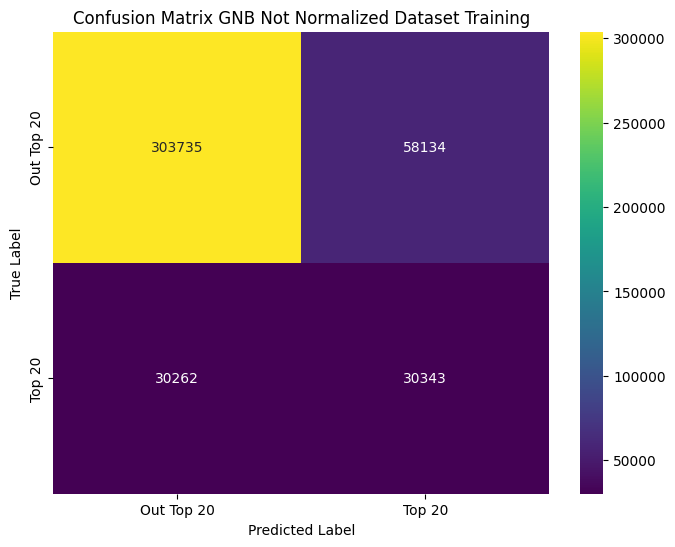

In [10]:
# confusion matrix
cm = confusion_matrix(y_train, y_train_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Not Normalized Dataset Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [11]:
y_pred = GNB.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.91      0.76      0.83     29163
           1       0.29      0.56      0.39      5095

    accuracy                           0.73     34258
   macro avg       0.60      0.66      0.61     34258
weighted avg       0.82      0.73      0.76     34258



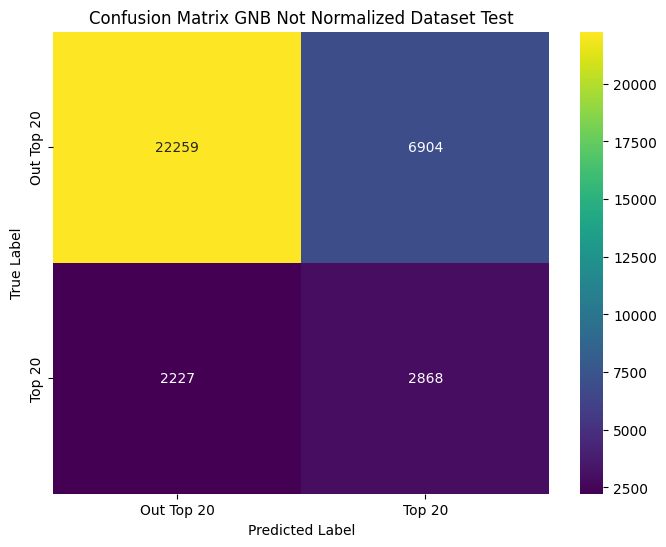

In [12]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Not Normalized Dataset Test")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [503]:
# save results
with open("./stuffs/results/GS/GNB_results.txt", "a") as file:  # 'a' in order to append results
    file.write(f"Model: {model_name}\n")
    file.write(f"Dataset: {dataset}\n")
    file.write(f"Feature Dataset: {features_dataset}\n")
    file.write("Classification Report:\n")
    file.write(scores + "\n")
    file.write("Confusion Matrix:\n")
    for row in cm:
        file.write("\t" + "\t".join(map(str, row)) + "\n")
    file.write("-" * 50 + "\n")  # in order to separate results from each other
    file.write("\n")

### Oversampling/Undersampling

In [504]:
model_name = "GNB"
dataset = "dataset_non_normalizzato_con_oversampling"
features_dataset = features

In [505]:
print("Train_set shape before dropping NaN:",train_set.shape)
print("Test_set shape before dropping NaN:",test_set.shape)
train_set = train_set.dropna()
test_set = test_set.dropna()
print("Train_set shape post dropping NaN:",train_set.shape)
print("Test_set shape post dropping NaN:",test_set.shape)

X_train = train_set[features]
y_train = train_set['top20']

X_test = test_set[features]
y_test = test_set['top20']

print("X_train shape:",X_train.shape)
print("y_train shape:",y_train.shape)
print("X_test shape:",X_test.shape)
print("y_test shape:",y_test.shape)

Train_set shape before dropping NaN: (422474, 35)
Test_set shape before dropping NaN: (34258, 35)
Train_set shape post dropping NaN: (422474, 35)
Test_set shape post dropping NaN: (34258, 35)
X_train shape: (422474, 5)
y_train shape: (422474,)
X_test shape: (34258, 5)
y_test shape: (34258,)


In [506]:
# Controlla la distribuzione originale
print("Distribuzione originale:", Counter(y_train))

Distribuzione originale: Counter({0: 361869, 1: 60605})


In [507]:
# Applica SMOTE (Oversampling)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [508]:
# Controlla la distribuzione dopo SMOTE
print("Distribuzione dopo SMOTE:", Counter(y_train_resampled))

Distribuzione dopo SMOTE: Counter({1: 361869, 0: 361869})


In [509]:
# modello da allenare
GNB = GaussianNB()     

In [510]:
GNB.fit(X_train_resampled, y_train_resampled)

GaussianNB()

In [511]:
y_train_resampled_pred = GNB.predict(X_train_resampled)
scores = classification_report(y_train_resampled,y_train_resampled_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.70      0.64      0.67    361869
           1       0.67      0.73      0.70    361869

    accuracy                           0.68    723738
   macro avg       0.68      0.68      0.68    723738
weighted avg       0.68      0.68      0.68    723738



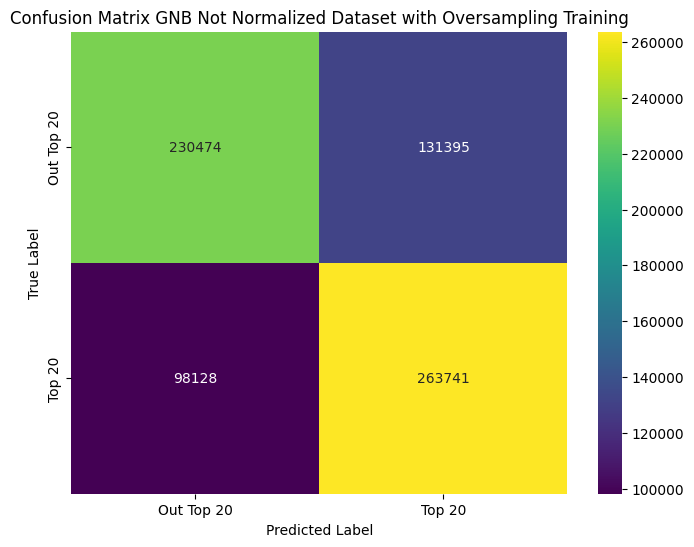

In [512]:
# confusion matrix
cm = confusion_matrix(y_train_resampled, y_train_resampled_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Not Normalized Dataset with Oversampling Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [513]:
y_pred = GNB.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.93      0.55      0.69     29163
           1       0.23      0.78      0.35      5095

    accuracy                           0.58     34258
   macro avg       0.58      0.66      0.52     34258
weighted avg       0.83      0.58      0.64     34258



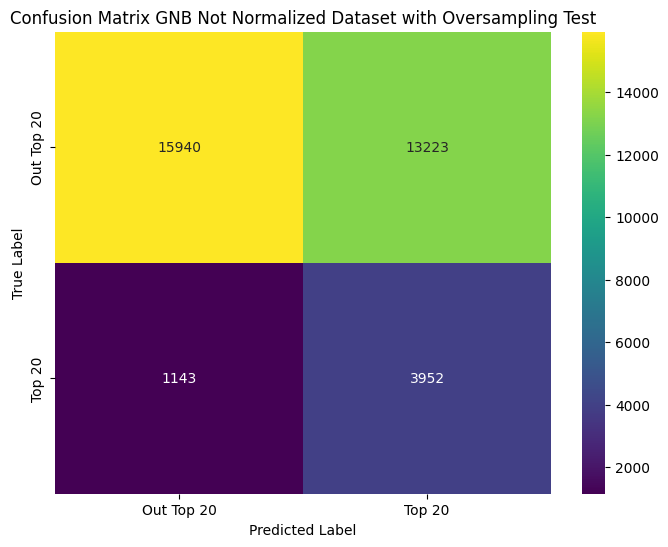

In [514]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Not Normalized Dataset with Oversampling Test")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [515]:
# # save results
# with open("./stuffs/results/GS/GNB_results.txt", "a") as file:  # 'a' in order to append results
#     file.write(f"Model: {model_name}\n")
#     file.write(f"Dataset: {dataset}\n")
#     file.write(f"Feature Dataset: {features_dataset}\n")
#     file.write("Classification Report:\n")
#     file.write(scores + "\n")
#     file.write("Confusion Matrix:\n")
#     for row in cm:
#         file.write("\t" + "\t".join(map(str, row)) + "\n")
#     file.write("-" * 50 + "\n")  # in order to separate results from each other
#     file.write("\n")

In [516]:
model_name = "GNB"
dataset = "dataset_non_normalizzato_con_undersampling"
features_dataset = features

In [517]:
# Controlla la distribuzione originale
print("Distribuzione originale:", Counter(y_train))

Distribuzione originale: Counter({0: 361869, 1: 60605})


In [518]:
# Applica Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

In [519]:
# Controlla la distribuzione dopo l'undersampling
print("Distribuzione dopo Random Undersampling:", Counter(y_train_resampled))

Distribuzione dopo Random Undersampling: Counter({0: 60605, 1: 60605})


In [520]:
# modello da allenare
GNB = GaussianNB()     

In [521]:
GNB.fit(X_train_resampled, y_train_resampled)

GaussianNB()

In [522]:
y_train_resampled_pred = GNB.predict(X_train_resampled)
scores = classification_report(y_train_resampled,y_train_resampled_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.70      0.64      0.67     60605
           1       0.67      0.72      0.69     60605

    accuracy                           0.68    121210
   macro avg       0.68      0.68      0.68    121210
weighted avg       0.68      0.68      0.68    121210



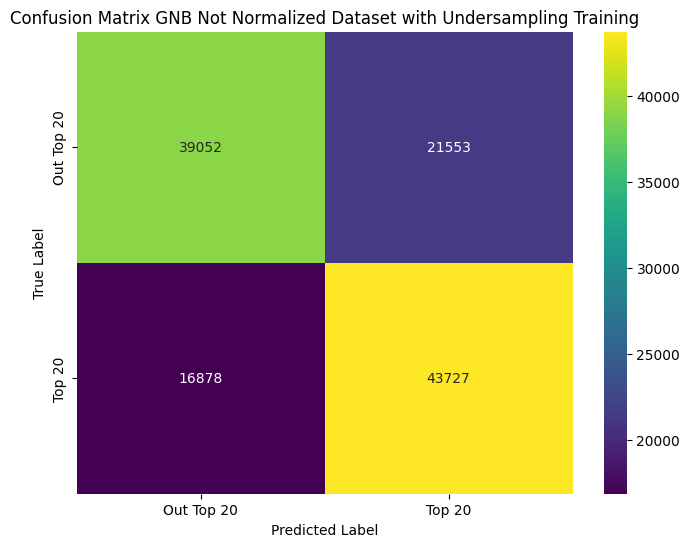

In [523]:
# confusion matrix
cm = confusion_matrix(y_train_resampled, y_train_resampled_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Not Normalized Dataset with Undersampling Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [524]:
y_pred = GNB.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.93      0.55      0.70     29163
           1       0.23      0.77      0.36      5095

    accuracy                           0.59     34258
   macro avg       0.58      0.66      0.53     34258
weighted avg       0.83      0.59      0.65     34258



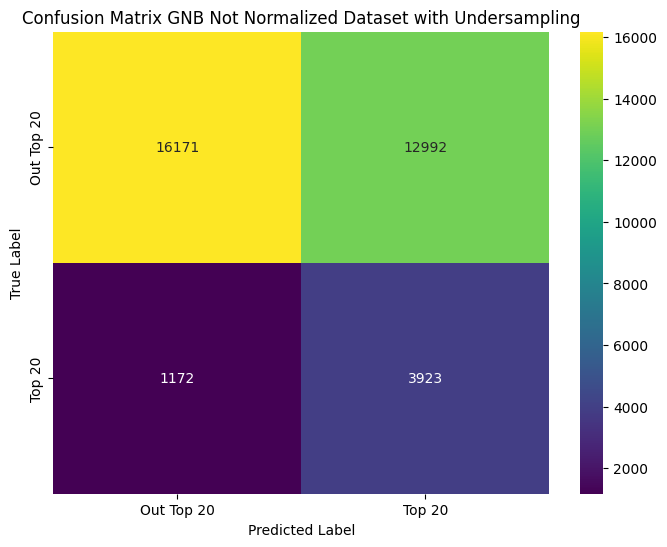

In [525]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Not Normalized Dataset with Undersampling")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [526]:
# # save results
# with open("./stuffs/results/GS/GNB_results.txt", "a") as file:  # 'a' in order to append results
#     file.write(f"Model: {model_name}\n")
#     file.write(f"Dataset: {dataset}\n")
#     file.write(f"Feature Dataset: {features_dataset}\n")
#     file.write("Classification Report:\n")
#     file.write(scores + "\n")
#     file.write("Confusion Matrix:\n")
#     for row in cm:
#         file.write("\t" + "\t".join(map(str, row)) + "\n")
#     file.write("-" * 50 + "\n")  # in order to separate results from each other
#     file.write("\n")

## Normalized dataset

In [13]:
# Take the normalized merged dataset cleaned from null values and anomalies
with gzip.open('./dataset/new_datasets/train_set_normalized.pkl', 'r') as file:
    train_set_n = pickle.load(file)
with gzip.open('./dataset/new_datasets/test_set_normalized.pkl', 'r') as file:
    test_set_n = pickle.load(file)

In [14]:
model_name = "GNB"
dataset = "dataset_normalizzato"
features_dataset = features_n

In [15]:
print("Train_set shape before dropping NaN:",train_set_n.shape)
print("Test_set shape before dropping NaN:",test_set_n.shape)
train_set_n = train_set_n.dropna()
test_set_n = test_set_n.dropna()
print("Train_set shape post dropping NaN:",train_set_n.shape)
print("Test_set shape post dropping NaN:",test_set_n.shape)

X_train = train_set_n[features_n]
y_train = train_set_n['top20']

X_test = test_set_n[features_n]
y_test = test_set_n['top20']

print("X_train shape:",X_train.shape)
print("y_train shape:",y_train.shape)
print("X_test shape:",X_test.shape)
print("y_test shape:",y_test.shape)

Train_set shape before dropping NaN: (439070, 37)
Test_set shape before dropping NaN: (35406, 37)
Train_set shape post dropping NaN: (426364, 37)
Test_set shape post dropping NaN: (34509, 37)
X_train shape: (426364, 8)
y_train shape: (426364,)
X_test shape: (34509, 8)
y_test shape: (34509,)


In [16]:
# modello da allenare
GNB = GaussianNB()  

In [17]:
GNB.fit(X_train, y_train)

GaussianNB()

In [18]:
y_train_pred = GNB.predict(X_train)
scores = classification_report(y_train,y_train_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.91      0.82      0.86    365347
           1       0.33      0.53      0.40     61017

    accuracy                           0.78    426364
   macro avg       0.62      0.67      0.63    426364
weighted avg       0.83      0.78      0.80    426364



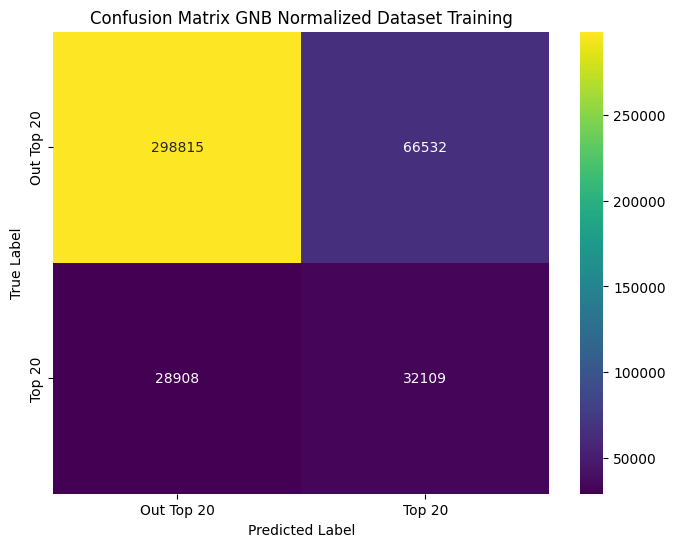

In [19]:
# confusion matrix
cm = confusion_matrix(y_train, y_train_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Normalized Dataset Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [20]:
y_pred = GNB.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.90      0.86      0.88     29391
           1       0.36      0.45      0.40      5118

    accuracy                           0.80     34509
   macro avg       0.63      0.65      0.64     34509
weighted avg       0.82      0.80      0.81     34509



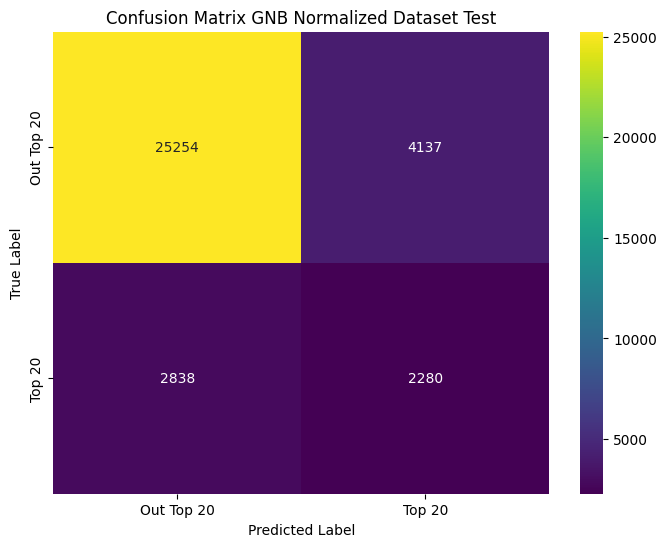

In [21]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Normalized Dataset Test")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [536]:
# # save results
# with open("./stuffs/results/GS/GNB_results.txt", "a") as file:  # 'a' in order to append results
#     file.write(f"Model: {model_name}\n")
#     file.write(f"Dataset: {dataset}\n")
#     file.write(f"Feature Dataset: {features_dataset}\n")
#     file.write("Classification Report:\n")
#     file.write(scores + "\n")
#     file.write("Confusion Matrix:\n")
#     for row in cm:
#         file.write("\t" + "\t".join(map(str, row)) + "\n")
#     file.write("-" * 50 + "\n")  # in order to separate results from each other
#     file.write("\n")

### Oversampling/Undersampling

In [537]:
model_name = "GNB"
dataset = "dataset_normalizzato_con_oversampling"
features_dataset = features_n

In [538]:
print("Train_set shape before dropping NaN:",train_set_n.shape)
print("Test_set shape before dropping NaN:",test_set_n.shape)
train_set_n = train_set_n.dropna()
test_set_n = test_set_n.dropna()
print("Train_set shape post dropping NaN:",train_set_n.shape)
print("Test_set shape post dropping NaN:",test_set_n.shape)

X_train = train_set_n[features_n]
y_train = train_set_n['top20']

X_test = test_set_n[features_n]
y_test = test_set_n['top20']

print("X_train shape:",X_train.shape)
print("y_train shape:",y_train.shape)
print("X_test shape:",X_test.shape)
print("y_test shape:",y_test.shape)

Train_set shape before dropping NaN: (426364, 37)
Test_set shape before dropping NaN: (34509, 37)
Train_set shape post dropping NaN: (426364, 37)
Test_set shape post dropping NaN: (34509, 37)
X_train shape: (426364, 5)
y_train shape: (426364,)
X_test shape: (34509, 5)
y_test shape: (34509,)


In [539]:
# Controlla la distribuzione originale
print("Distribuzione originale:", Counter(y_train))

Distribuzione originale: Counter({0: 365347, 1: 61017})


In [540]:
# Applica SMOTE (Oversampling)
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [541]:
# Controlla la distribuzione dopo SMOTE
print("Distribuzione dopo SMOTE:", Counter(y_train_resampled))

Distribuzione dopo SMOTE: Counter({0: 365347, 1: 365347})


In [542]:
# modello da allenare
GNB = GaussianNB()     

In [543]:
GNB.fit(X_train_resampled, y_train_resampled)

GaussianNB()

In [544]:
y_train_resampled_pred = GNB.predict(X_train_resampled)
scores = classification_report(y_train_resampled,y_train_resampled_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.70      0.66      0.68    365347
           1       0.68      0.71      0.69    365347

    accuracy                           0.69    730694
   macro avg       0.69      0.69      0.68    730694
weighted avg       0.69      0.69      0.68    730694



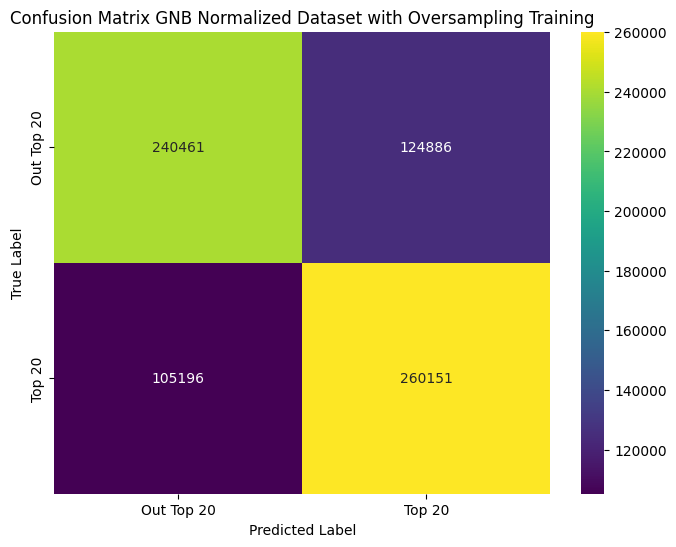

In [545]:
# confusion matrix
cm = confusion_matrix(y_train_resampled, y_train_resampled_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Normalized Dataset with Oversampling Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [546]:
y_pred = GNB.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.92      0.70      0.79     29391
           1       0.27      0.64      0.38      5118

    accuracy                           0.69     34509
   macro avg       0.59      0.67      0.58     34509
weighted avg       0.82      0.69      0.73     34509



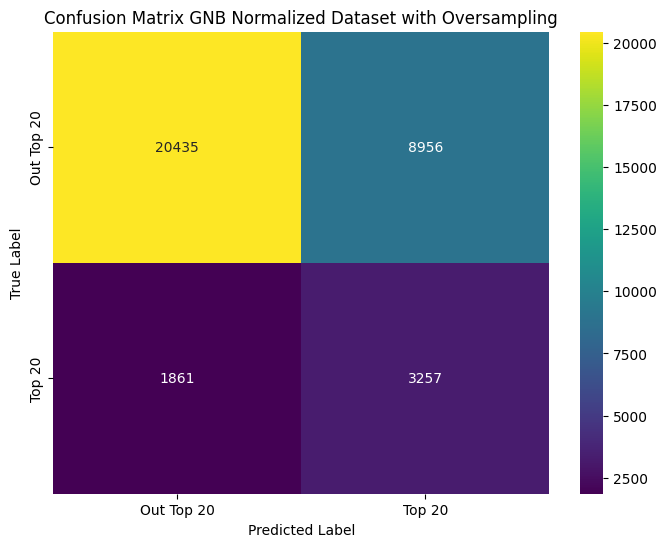

In [547]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Normalized Dataset with Oversampling")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [548]:
# # save results
# with open("./stuffs/results/GS/GNB_results.txt", "a") as file:  # 'a' in order to append results
#     file.write(f"Model: {model_name}\n")
#     file.write(f"Dataset: {dataset}\n")
#     file.write(f"Feature Dataset: {features_dataset}\n")
#     file.write("Classification Report:\n")
#     file.write(scores + "\n")
#     file.write("Confusion Matrix:\n")
#     for row in cm:
#         file.write("\t" + "\t".join(map(str, row)) + "\n")
#     file.write("-" * 50 + "\n")  # in order to separate results from each other
#     file.write("\n")

In [549]:
model_name = "GNB"
dataset = "dataset_normalizzato_con_undersampling"
features_dataset = features_n

In [550]:
# Controlla la distribuzione originale
print("Distribuzione originale:", Counter(y_train))

Distribuzione originale: Counter({0: 365347, 1: 61017})


In [551]:
# Applica Random Undersampling
rus = RandomUnderSampler(random_state=42)
X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

In [552]:
# Controlla la distribuzione dopo l'undersampling
print("Distribuzione dopo Random Undersampling:", Counter(y_train_resampled))

Distribuzione dopo Random Undersampling: Counter({0: 61017, 1: 61017})


In [553]:
# modello da allenare
GNB = GaussianNB()     

In [554]:
GNB.fit(X_train_resampled, y_train_resampled)

GaussianNB()

In [555]:
y_train_resampled_pred = GNB.predict(X_train_resampled)
scores = classification_report(y_train_resampled,y_train_resampled_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.67      0.69      0.68     61017
           1       0.68      0.66      0.67     61017

    accuracy                           0.68    122034
   macro avg       0.68      0.68      0.68    122034
weighted avg       0.68      0.68      0.68    122034



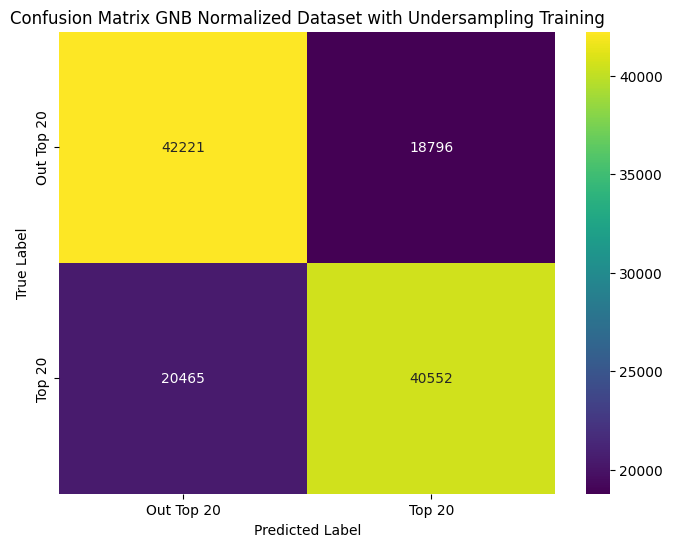

In [556]:
# confusion matrix
cm = confusion_matrix(y_train_resampled, y_train_resampled_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Normalized Dataset with Undersampling Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [557]:
y_pred = GNB.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.92      0.72      0.81     29391
           1       0.28      0.62      0.38      5118

    accuracy                           0.70     34509
   macro avg       0.60      0.67      0.59     34509
weighted avg       0.82      0.70      0.74     34509



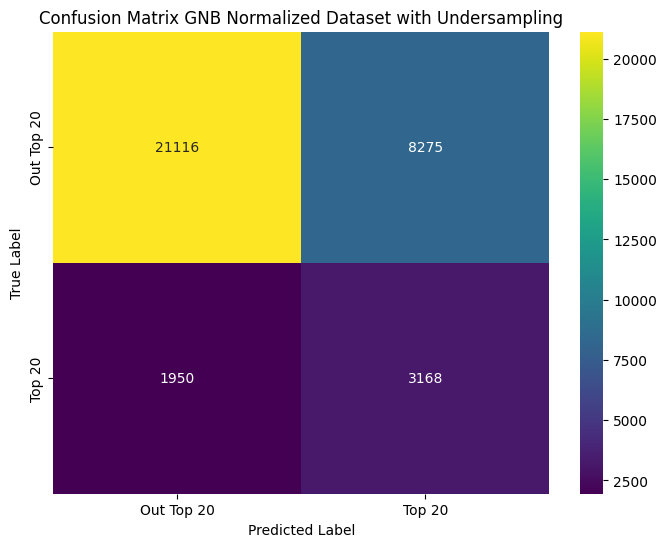

In [558]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Normalized Dataset with Undersampling")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [559]:
# # save results
# with open("./stuffs/results/GS/GNB_results.txt", "a") as file:  # 'a' in order to append results
#     file.write(f"Model: {model_name}\n")
#     file.write(f"Dataset: {dataset}\n")
#     file.write(f"Feature Dataset: {features_dataset}\n")
#     file.write("Classification Report:\n")
#     file.write(scores + "\n")
#     file.write("Confusion Matrix:\n")
#     for row in cm:
#         file.write("\t" + "\t".join(map(str, row)) + "\n")
#     file.write("-" * 50 + "\n")  # in order to separate results from each other
#     file.write("\n")

## Standardizzazione datasets

###  Not normalized dataset

In [560]:
# Take the merged dataset cleaned from null values and anomalies
with gzip.open('./dataset/new_datasets/train_set.pkl', 'r') as file:
    train_set = pickle.load(file)
with gzip.open('./dataset/new_datasets/test_set.pkl', 'r') as file:
    test_set = pickle.load(file)

In [561]:
model_name = "GNB"
dataset = "dataset_non_normalizzato_standardizzato"
features_dataset = features

In [562]:
print("Train_set shape before dropping NaN:",train_set.shape)
print("Test_set shape before dropping NaN:",test_set.shape)
train_set = train_set.dropna()
test_set = test_set.dropna()
print("Train_set shape post dropping NaN:",train_set.shape)
print("Test_set shape post dropping NaN:",test_set.shape)

X_train = train_set[features]
y_train = train_set['top20']

X_test = test_set[features]
y_test = test_set['top20']

print("X_train shape:",X_train.shape)
print("y_train shape:",y_train.shape)
print("X_test shape:",X_test.shape)
print("y_test shape:",y_test.shape)

Train_set shape before dropping NaN: (439070, 35)
Test_set shape before dropping NaN: (35406, 35)
Train_set shape post dropping NaN: (422474, 35)
Test_set shape post dropping NaN: (34258, 35)
X_train shape: (422474, 5)
y_train shape: (422474,)
X_test shape: (34258, 5)
y_test shape: (34258,)


In [563]:
X_train

,avg_position,performance_wma,top20_consistency,races_dby_consistency,participants
436,12.750000,13.555556,3.0,1.333333,106
437,9.250000,9.111111,3.0,1.333333,106
438,27.250000,25.777778,1.0,4.000000,106
439,43.750000,41.925926,1.0,4.000000,106
440,89.000000,90.740741,0.0,4.000000,106
...,...,...,...,...,...
439064,69.571429,64.608133,1.0,35.000000,107
439065,79.868421,80.619584,4.0,19.000000,107
439066,103.073446,100.653879,8.0,44.250000,107
439067,81.697917,150.315647,12.0,24.000000,107


In [564]:
# Standardizza i dati (fondamentale per il modello Gaussian Naive Bayes che si aspetta che i dati seguano una distribuzione gaussiana (normale))
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [565]:
X_train

array([[-2.71778329, -1.91710852, -0.56994676, -0.71379467, -1.85739019],
       [-2.86148583, -2.04806234, -0.56994676, -0.71379467, -1.85739019],
       [-2.12244423, -1.55698549, -0.62801841, -0.57111956, -1.85739019],
       ...,
       [ 0.99070471,  0.64920973, -0.42476761,  1.58238285, -1.82245152],
       [ 0.11307107,  2.1124744 , -0.30862429,  0.49894375, -1.82245152],
       [-0.89823551, -1.18524756, -0.59898258, -0.38385848, -1.82245152]],
      shape=(422474, 5))

In [566]:
# modello da allenare
GNB = GaussianNB()     

In [567]:
GNB.fit(X_train, y_train)

GaussianNB()

In [568]:
y_train_pred = GNB.predict(X_train)
scores = classification_report(y_train,y_train_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.90      0.87      0.89    361869
           1       0.36      0.42      0.39     60605

    accuracy                           0.81    422474
   macro avg       0.63      0.65      0.64    422474
weighted avg       0.82      0.81      0.81    422474



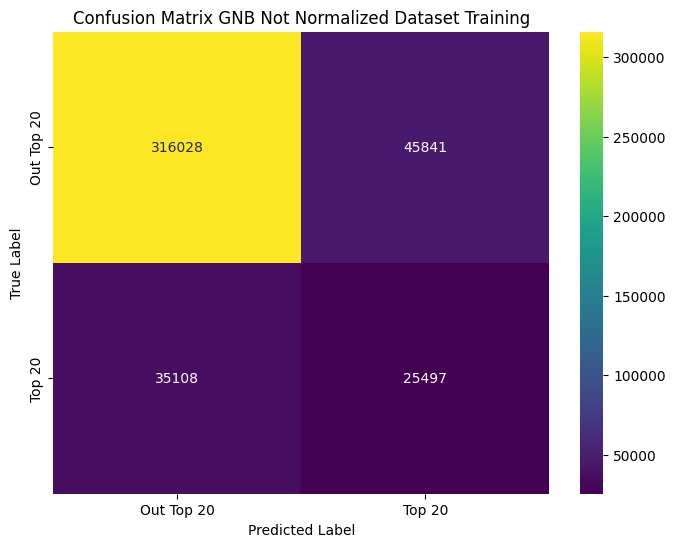

In [569]:
# confusion matrix
cm = confusion_matrix(y_train, y_train_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Not Normalized Dataset Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [570]:
y_pred = GNB.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.90      0.79      0.84     29163
           1       0.30      0.50      0.37      5095

    accuracy                           0.75     34258
   macro avg       0.60      0.65      0.61     34258
weighted avg       0.81      0.75      0.77     34258



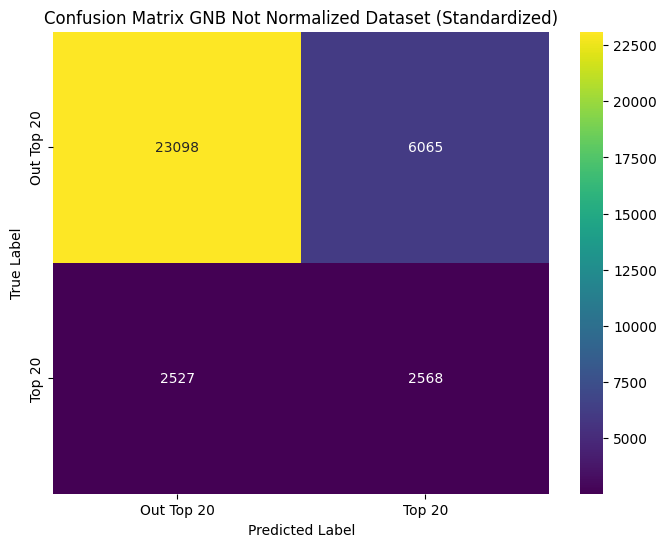

In [571]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Not Normalized Dataset (Standardized)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [572]:
# # save results
# with open("./stuffs/results/GS/GNB_results.txt", "a") as file:  # 'a' in order to append results
#     file.write(f"Model: {model_name}\n")
#     file.write(f"Dataset: {dataset}\n")
#     file.write(f"Feature Dataset: {features_dataset}\n")
#     file.write("Classification Report:\n")
#     file.write(scores + "\n")
#     file.write("Confusion Matrix:\n")
#     for row in cm:
#         file.write("\t" + "\t".join(map(str, row)) + "\n")
#     file.write("-" * 50 + "\n")  # in order to separate results from each other
#     file.write("\n")

### Normalized dataset

In [573]:
# Take the normalized merged dataset cleaned from null values and anomalies
with gzip.open('./dataset/new_datasets/train_set_normalized.pkl', 'r') as file:
    train_set_n = pickle.load(file)
with gzip.open('./dataset/new_datasets/test_set_normalized.pkl', 'r') as file:
    test_set_n = pickle.load(file)

In [574]:
model_name = "GNB"
dataset = "dataset_normalizzato_standardizzato"
features_dataset = features_n

In [575]:
print("Train_set shape before dropping NaN:",train_set_n.shape)
print("Test_set shape before dropping NaN:",test_set_n.shape)
train_set_n = train_set_n.dropna()
test_set_n = test_set_n.dropna()
print("Train_set shape post dropping NaN:",train_set_n.shape)
print("Test_set shape post dropping NaN:",test_set_n.shape)

X_train = train_set_n[features_n]
y_train = train_set_n['top20']

X_test = test_set_n[features_n]
y_test = test_set_n['top20']

print("X_train shape:",X_train.shape)
print("y_train shape:",y_train.shape)
print("X_test shape:",X_test.shape)
print("y_test shape:",y_test.shape)

Train_set shape before dropping NaN: (439070, 37)
Test_set shape before dropping NaN: (35406, 37)
Train_set shape post dropping NaN: (426364, 37)
Test_set shape post dropping NaN: (34509, 37)
X_train shape: (426364, 5)
y_train shape: (426364,)
X_test shape: (34509, 5)
y_test shape: (34509,)


In [576]:
X_train

,avg_position_startlist,performance_wma,top20_consistency,races_dby_consistency,participants
328,0.041096,0.420795,3.0,1.0,108
329,0.018265,0.226856,3.0,1.0,108
330,0.062047,0.727625,3.0,1.0,108
331,0.056675,0.672282,3.0,1.0,108
332,0.047811,0.459179,3.0,1.0,108
...,...,...,...,...,...
439064,0.096477,0.544933,35.0,1.0,107
439065,0.100568,0.673784,76.0,1.0,107
439066,0.102738,0.793265,354.0,1.0,107
439067,0.087596,0.847997,288.0,1.0,107


In [577]:
# Standardizza i dati (fondamentale per il modello Gaussian Naive Bayes che si aspetta che i dati seguano una distribuzione gaussiana (normale))
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [578]:
X_train

array([[-1.09466797, -0.36813325, -1.04742545,  0.        , -1.78205976],
       [-1.87557976, -1.35738932, -1.04742545,  0.        , -1.78205976],
       [-0.37806657,  1.19695986, -1.04742545,  0.        , -1.78205976],
       ...,
       [ 1.01373794,  1.5317819 ,  1.81615958,  0.        , -1.81689026],
       [ 0.49582982,  1.81096197,  1.27770769,  0.        , -1.81689026],
       [-0.15225464, -1.05862328, -0.94952511,  0.        , -1.81689026]],
      shape=(426364, 5))

In [579]:
# modello da allenare
GNB = GaussianNB()  

In [580]:
GNB.fit(X_train, y_train)

GaussianNB()

In [581]:
y_train_pred = GNB.predict(X_train)
scores = classification_report(y_train,y_train_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.88      0.96      0.92    365347
           1       0.47      0.20      0.28     61017

    accuracy                           0.85    426364
   macro avg       0.67      0.58      0.60    426364
weighted avg       0.82      0.85      0.83    426364



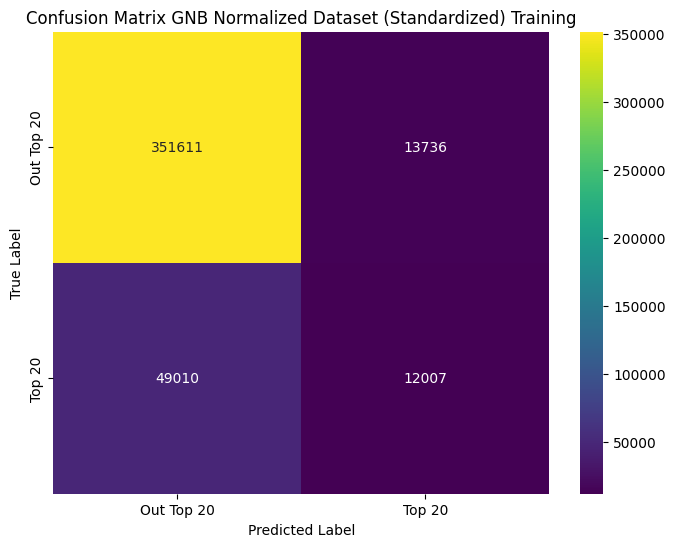

In [582]:
# confusion matrix
cm = confusion_matrix(y_train, y_train_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Normalized Dataset (Standardized) Training")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [583]:
y_pred = GNB.predict(X_test)
scores = classification_report(y_test,y_pred)
print(scores)

              precision    recall  f1-score   support

           0       0.87      0.97      0.92     29391
           1       0.48      0.17      0.25      5118

    accuracy                           0.85     34509
   macro avg       0.67      0.57      0.59     34509
weighted avg       0.81      0.85      0.82     34509



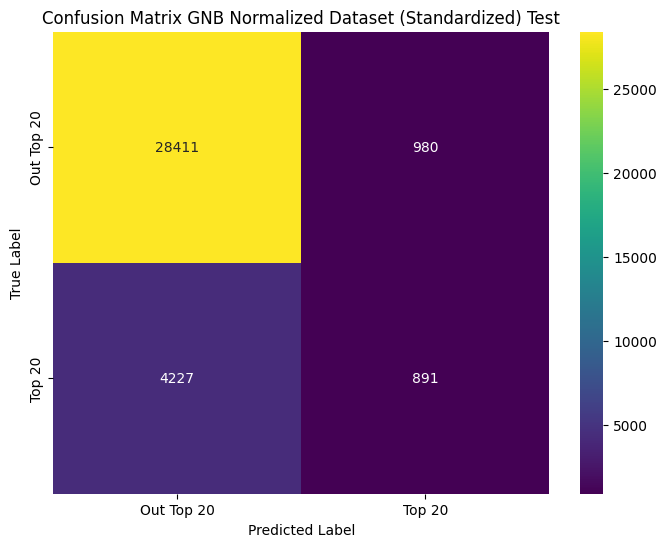

In [584]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Heatmap della matrice di confusione
plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Class 0', 'Class 1'], yticklabels=['Class 0', 'Class 1'])
sns.heatmap(cm, annot=True, fmt="d", cmap="viridis", xticklabels=['Out Top 20', 'Top 20'], yticklabels=['Out Top 20', 'Top 20'])
plt.title("Confusion Matrix GNB Normalized Dataset (Standardized) Test")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

In [585]:
# # save results
# with open("./stuffs/results/GS/GNB_results.txt", "a") as file:  # 'a' in order to append results
#     file.write(f"Model: {model_name}\n")
#     file.write(f"Dataset: {dataset}\n")
#     file.write(f"Feature Dataset: {features_dataset}\n")
#     file.write("Classification Report:\n")
#     file.write(scores + "\n")
#     file.write("Confusion Matrix:\n")
#     for row in cm:
#         file.write("\t" + "\t".join(map(str, row)) + "\n")
#     file.write("-" * 50 + "\n")  # in order to separate results from each other
#     file.write("\n")